In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/accidents_processed.csv')

df['high_risk'] = (df['Severity'] >= 3).astype(int)

X = df.drop(['Severity','high_risk','cluster'], axis=1, errors='ignore')
y = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.66      0.64      8257
           1       0.54      0.49      0.52      6752

    accuracy                           0.59     15009
   macro avg       0.58      0.58      0.58     15009
weighted avg       0.58      0.59      0.58     15009



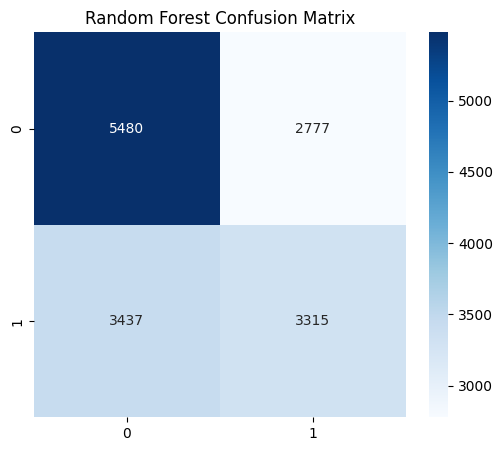

In [5]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.savefig('../results/confusion_rf.png', bbox_inches='tight')
plt.show()

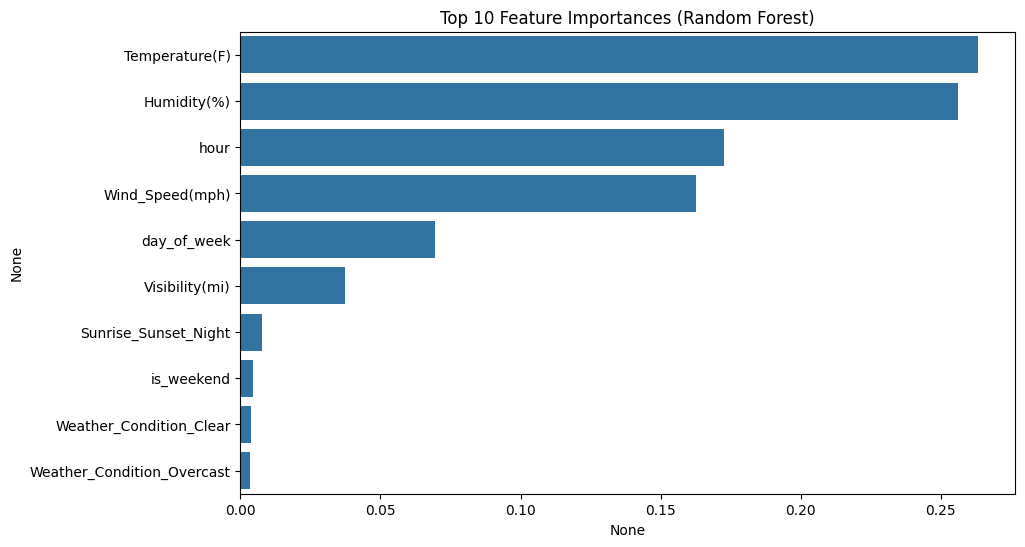

In [6]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.savefig('../results/feature_importance_rf.png', bbox_inches='tight')
plt.show()

In [7]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.62      0.61      8257
           1       0.51      0.49      0.50      6752

    accuracy                           0.56     15009
   macro avg       0.56      0.55      0.55     15009
weighted avg       0.56      0.56      0.56     15009

